In [10]:
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

from pathlib import Path
from dotenv import load_dotenv
from soundcharts import SoundchartsClientAsync

load_dotenv()

app_id = (os.getenv("SOUNDCHARTS_APP_ID") or "").strip()
api_key = (os.getenv("SOUNDCHARTS_API_KEY") or "").strip()

# Remember to use async client — Jupyter runs in an async context, so the sync client would raise.
sc = SoundchartsClientAsync(app_id=app_id, api_key=api_key)
sc

SoundchartsClientAsync(base_url=https://customer.api.soundcharts.com)

In [11]:
# Using Soundcharts SDK and API...
# Need Song UUID

example_song_uuid_1 = "2ffc5f25-f191-4551-a1b4-40fe9ddcc075"
song_ids = await sc.song.get_ids(example_song_uuid_1)

In [12]:
tiktok_identifiers = []
instagram_identifiers = []

for platform in song_ids['items']:
    if platform['platformName'] == 'TikTok':
        tiktok_identifiers.append(platform['identifier'])
    if platform['platformName'] == 'Instagram':
        instagram_identifiers.append(platform['identifier'])

print(tiktok_identifiers)
print(instagram_identifiers)

['6828369207952935686', '6831299278208501761', '6831392046343800833']
['674884816624269']


In [25]:
tiktok_music_video_count = await sc.tiktok.get_music_video_count(tiktok_identifiers[2])

# example_song_uuid_2 = "7d534228-5165-11e9-9375-549f35161576"

# instagram_music_video_count_1 = await sc.song.get_audience(example_song_uuid_1, platform='instagram')
# instagram_music_video_count_2 = await sc.song.get_audience(example_song_uuid_2, platform='instagram')

2026-02-23 16:46:39,178 [ERROR] 403 Error: Access Denied. If you think this is an error, please contact us. when calling https://customer.api.soundcharts.com/api/v2/tiktok/music/6831392046343800833/video/volume?period=90


RuntimeError: 403 Error: Access Denied. If you think this is an error, please contact us. when calling https://customer.api.soundcharts.com/api/v2/tiktok/music/6831392046343800833/video/volume?period=90

In [23]:

instagram_music_video_count_2 = await sc.song.get_audience(example_song_uuid_2, platform='instagram', end_date='2025-08-01')
instagram_music_video_count_2


{'related': {'uuid': '7d534228-5165-11e9-9375-549f35161576',
  'name': 'bad guy',
  'creditName': 'Billie Eilish',
  'imageUrl': 'https://assets.soundcharts.com/song/5/6/1/7d534228-5165-11e9-9375-549f35161576.jpg'},
 'items': [{'date': '2025-07-30T00:00:00+00:00',
   'plots': [{'identifier': '410792822988663', 'value': 291076}]},
  {'date': '2025-07-23T00:00:00+00:00',
   'plots': [{'identifier': '410792822988663', 'value': 290602}]},
  {'date': '2025-07-16T00:00:00+00:00',
   'plots': [{'identifier': '410792822988663', 'value': 290095}]},
  {'date': '2025-07-09T00:00:00+00:00',
   'plots': [{'identifier': '410792822988663', 'value': 289720}]},
  {'date': '2025-07-02T00:00:00+00:00',
   'plots': [{'identifier': '410792822988663', 'value': 289205}]},
  {'date': '2025-06-25T00:00:00+00:00',
   'plots': [{'identifier': '410792822988663', 'value': 288808}]},
  {'date': '2025-06-18T00:00:00+00:00',
   'plots': [{'identifier': '410792822988663', 'value': 288375}]},
  {'date': '2025-06-11T00:

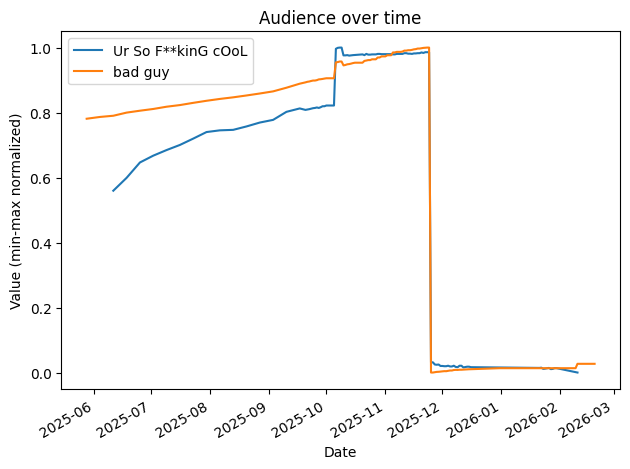

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

def series_from_response(response):
    dates = []
    values = []
    for item in response["items"]:
        dates.append(pd.to_datetime(item["date"]))
        values.append(sum(p["value"] for p in item["plots"]))
    return pd.DataFrame({"date": dates, "value": values}).sort_values("date")

df1 = series_from_response(instagram_music_video_count_1)
df2 = series_from_response(instagram_music_video_count_2)

# Min-max normalize each series to [0, 1] for comparable scale
def minmax_norm(s):
    lo, hi = s.min(), s.max()
    if hi == lo:
        return pd.Series(0.5, index=s.index)
    return (s - lo) / (hi - lo)

df1 = df1.assign(value_norm=minmax_norm(df1["value"]))
df2 = df2.assign(value_norm=minmax_norm(df2["value"]))

label1 = instagram_music_video_count_1.get("related", {}).get("name", "Count 1")
label2 = instagram_music_video_count_2.get("related", {}).get("name", "Count 2")

fig, ax = plt.subplots()
ax.plot(df1["date"], df1["value_norm"], label=label1)
ax.plot(df2["date"], df2["value_norm"], label=label2)
ax.set_xlabel("Date")
ax.set_ylabel("Value (min-max normalized)")
ax.set_title("Audience over time")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()